In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (16, 10),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
LDN_tz = pytz.timezone("Europe/London") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../")

from RVUtils.plt_timeseries import make_secondary_axis_plot

In [2]:
from MDP.USTFutures.USTFutureOptionMDP import USTFutureOptionMDP
from MDP.IRSwaptions.IRSwaptionMDP import IRSwaptionMDP

from TB.TimeseriesBuilder import TimeseriesBuilder
from TB.USTFutureOptionsTB import USTFutureOptionsTB 
from TB.IRSwaptionsTB import IRSwaptionsTB 

from Query.USTFutureOptions import USTFutureOptionQuery, USTFutureOptionStructure, USTFutureOptionValue
from Query.IRSwaptions import IRSwaptionQuery, IRSwaptionStructure, IRSwaptionValue

from BT.misc import ql_cal_date_range

from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP

(<Figure size 1600x1000 with 1 Axes>,
 <Axes: >,
  <matplotlib.lines.Line2D at 0x1bd1752f750>])

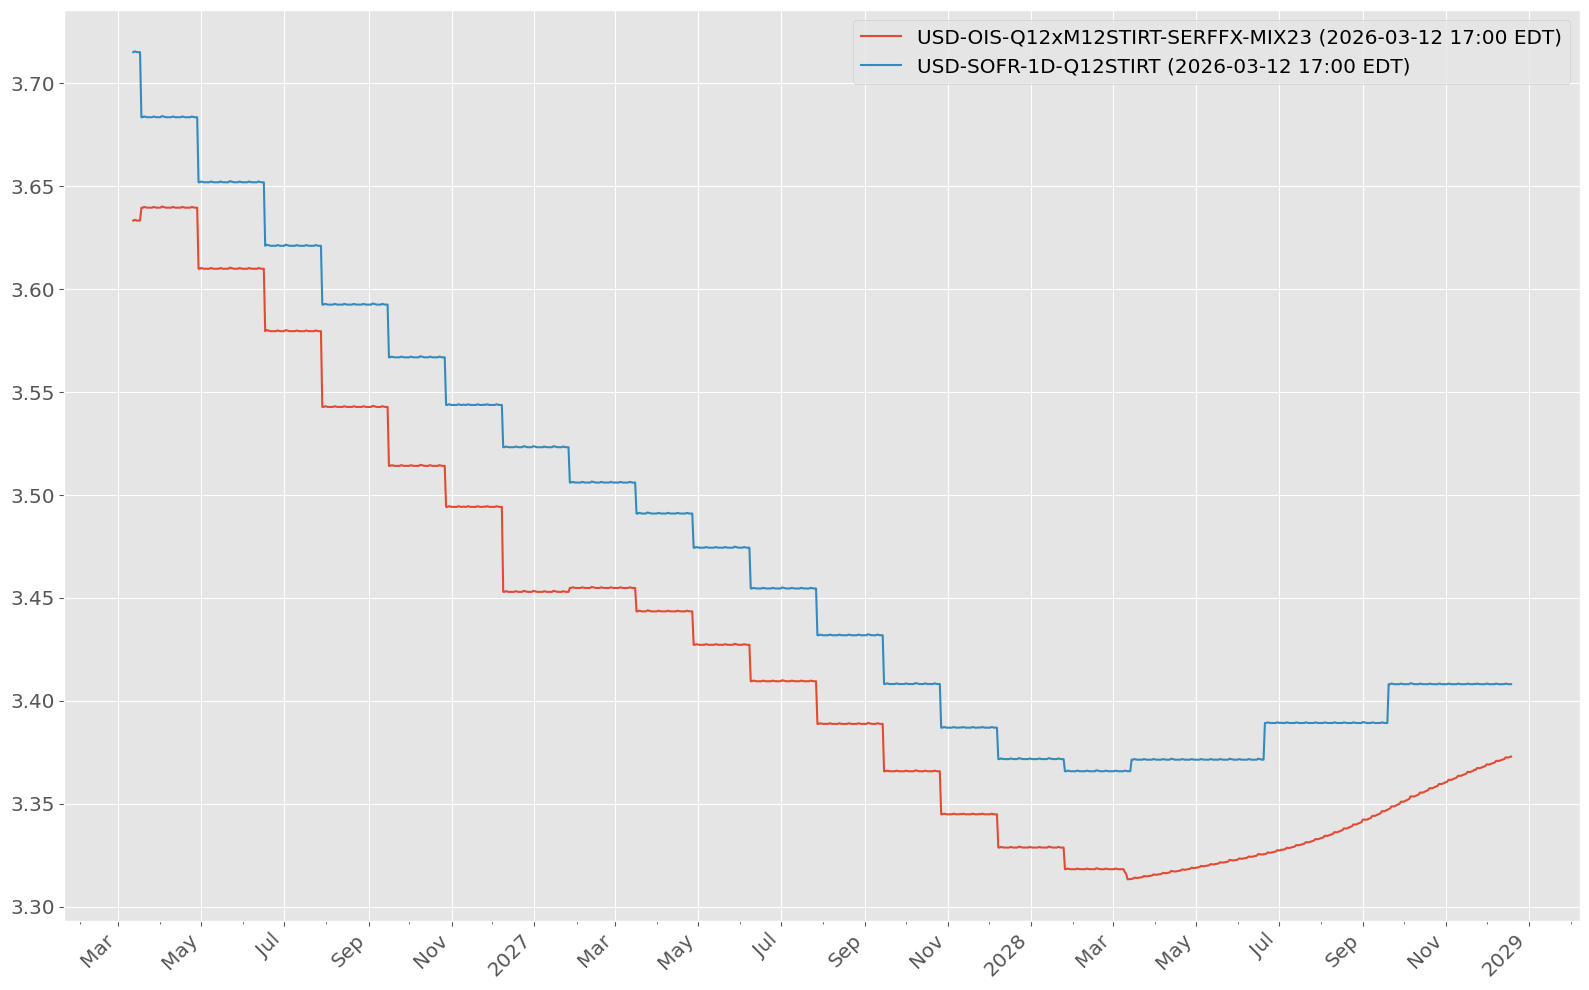

In [5]:
from MDP.IRSwaps.BARCHART_STIRF.rl import BARCHART_STIRF_CURVE, plot_overnight_forward_curves

bc_stirf_curve = BARCHART_STIRF_CURVE()

plot_overnight_forward_curves(
	curves=[
		# bc_stirf_curve.build_curve(
		# 	curve_name="USD-SOFR-1D-Q12STIRT",
		# 	timestamp=NY_tz.localize(datetime.datetime(2026, 3, 5, 12, 19)),
		# 	kwargs={"force_refresh": True, "cache_full_intraday_fetch": True},
		# ),
        # bc_stirf_curve.build_curve(
		# 	curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
			# timestamp=NY_tz.localize(datetime.datetime(2026, 3, 11, 17, 00)),
		# 	# kwargs={"force_refresh": True, "cache_full_intraday_fetch": True},

		# ),
		bc_stirf_curve.build_curve(
			curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
			timestamp=NY_tz.localize(datetime.datetime(2026, 3, 12, 17, 00)),
			# timestamp="live",
			# kwargs={"force_refresh": True, "cache_full_intraday_fetch": True},
		),
		bc_stirf_curve.build_curve(
			curve_name="USD-SOFR-1D-Q12STIRT",
			timestamp=NY_tz.localize(datetime.datetime(2026, 3, 12, 17, 00)),
		),
		# bc_stirf_curve.build_curve(
		# 	curve_name="USD-SOFR-1D-Q12STIRT",
		# 	timestamp=NY_tz.localize(datetime.datetime(2023, 3, 13, 7, 00)),
		# ),
		# bc_stirf_curve.build_curve(
		# 	curve_name="USD-SOFR-1D-Q12STIRT",
		# 	timestamp=NY_tz.localize(datetime.datetime(2023, 3, 13, 17, 00)),
		# ),
	]
)

In [3]:
mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")


def plot_sfr_smile(smile):
	pts = sorted(smile.points, key=lambda p: p.strike_rate)
	call_pts = [p for p in pts if p.right == "C"]
	put_pts = [p for p in pts if p.right == "P"]

	# Smooth strike grid in rate space
	x_min = min(p.strike_rate for p in pts) - 0.10
	x_max = max(p.strike_rate for p in pts) + 0.10
	strike_grid = np.linspace(x_min, x_max, 400)

	# Model vols from fitted SABR smile
	sabr_vols_bps = smile.normal_vol(
		strike_grid,
		strike_space="rate",
		vol_units="bps",
	)

	fig, ax = plt.subplots(figsize=(10, 6))

	# Smooth SABR curve
	ax.plot(
		strike_grid,
		sabr_vols_bps,
		color="black",
		lw=2,
		label="SABR fit",
	)

	# Market vols
	ax.scatter(
		[p.strike_rate for p in put_pts],
		[p.iv_normal_bps for p in put_pts],
		color="tab:blue",
		s=40,
		label="Put market vols",
	)
	ax.scatter(
		[p.strike_rate for p in call_pts],
		[p.iv_normal_bps for p in call_pts],
		color="tab:orange",
		s=40,
		label="Call market vols",
	)

	ax.axvline(
		smile.params.forward_rate,
		color="gray",
		ls="--",
		lw=1,
		label="ATM",
	)

	for p in pts:
		ax.annotate(
			p.label.split("|")[-1],
			(p.strike_rate, p.iv_normal_bps),
			xytext=(4, 4),
			textcoords="offset points",
			fontsize=8,
		)

	ax.set_title(f"{smile.symbol} SABR Smile as of {smile.params.as_of}")
	ax.set_xlabel("Strike Rate")
	ax.set_ylabel("Normal Vol (bps)")
	ax.grid(True, alpha=0.3)
	ax.legend()
	plt.tight_layout()
	plt.show()

In [6]:
# otc_listed_vol_tb = TimeseriesBuilder(
#     irswaptions_tb=IRSwaptionsTB(
#         IRSwaptionMDP(
#             source="GSQUANT-QL",
#             curve_source="ERIS_EOD_LIVE-QL_BASIC",
#         ),
#         show_tqdm=True,
#     ),
#     ustfutureoptions_tb=USTFutureOptionsTB(USTFutureOptionMDP(source="USTFO_DUAL-QL"), show_tqdm=True),
#     # ustfutureoptions_tb=USTFutureOptionsTB(USTFutureOptionMDP(source="BARCHART_USTFO-QL"), show_tqdm=True),
# )

In [7]:
# start = datetime.date(2025, 3, 15)
# end = datetime.date(2026, 3, 9)

# queries = [
    # USTFutureOptionQuery(symbol="TY_30|ATMS", value=USTFutureOptionValue.IV_NORMAL_BPS),
    # USTFutureOptionQuery(symbol="US_30|ATMS", value=USTFutureOptionValue.IV_NORMAL_BPS),

    # USTFutureOptionQuery(symbol="TYM26|ATMS", value=USTFutureOptionValue.IV_NORMAL_BPS),
    # IRSwaptionQuery(
    #     curve="USD-SOFR-1D",
    #     shorthand="1m7y",
    #     structure=IRSwaptionStructure.STRADDLE,
    #     strike="ATMF",
    #     value=IRSwaptionValue.NVOL,
    # ),
# ]

# df = otc_listed_vol_tb.get_timeseries(
#     start=start,
#     end=end,
#     queries=queries,
#     drop_multilevel_cols=True,
#     # ignore_cache=True
# )
# df

In [8]:
# plot, fig, ax, ax2, legend = make_secondary_axis_plot()
# plot(df["TY_30|ATMS OUTRIGHT IV_NORMAL_BPS"], which="left")
# # plot(df["USD-SOFR-1D 1Mx7Y STRADDLE BUY ATMF NVOL"], which="left")
# legend(show_date=True, loc="lower left")
# plt.show()

In [14]:
# python MDP/USTFutures/warm_ustfo_cache_parallel.py --start 2025-01-06 --end 2025-01-10 --chunks 5 --workers 5 --heartbeat-seconds 30 --report-json cache/ustfo_cache_warm_report.json

In [4]:
ustfo_bc_mdp = USTFutureOptionMDP(source="BARCHART_USTFO-QL")
ustfo_qs_mdp = USTFutureOptionMDP(source="USTFO_DUAL-QL")

In [ ]:
# as_of = datetime.date(2026, 3, 6)

# out = ustfo_bc_mdp.get_pricer({
#     "endpoint": "option_snapshot",
#     "symbols": ["TYM26|ATMS"],  
#     "timestamp": as_of,
#     "show_tqdm": True,
#     "use_ql_calculator": True,
# 	# "force_refresh": True
# })

# pr = next(iter(out.values()))[0]
# print("resolved_symbol:", pr.symbol())
# print("price:", pr.price(), "iv_normal_bps:", pr.iv_normal_bps())
# print("delta:", pr.delta(), "gamma:", pr.gamma(), "vega:", pr.vega(), "theta:", pr.theta())

In [14]:
as_of = datetime.date(2021, 3, 15)

out = ustfo_qs_mdp.get_pricer({
    "endpoint": "option_snapshot",
    "symbols": ["TY_30|ATMS"],  
    "timestamp": as_of,
    "show_tqdm": True,
    "use_ql_calculator": True,
})
out
pr = next(iter(out.values()))[0]
print("resolved_symbol:", pr.symbol())
print("price:", pr.price(), "iv_normal_bps:", pr.iv_normal_bps())
print("delta:", pr.delta(), "gamma:", pr.gamma(), "vega:", pr.vega(), "theta:", pr.theta())

FETCHING EOD DATA FROM BARCHART...: 100%|██████████| 1/1 [00:00<00:00,  1.08it/s]


SUCCESS: `conv_tol` reached after 3 iterations (levenberg_marquardt), `f_val`: 0.006391252312526294, `time`: 0.2670s
resolved_symbol: TY_30|ATMS
price: 1.676341897333375 iv_normal_bps: 91.5434161762265
delta: 0.029681736603037412 gamma: 0.37975091503897757 vega: 0.22858320696141998 theta: -10.183204278414717


FETCHING EOD DATA FROM BARCHART...: 100%|██████████| 1/1 [00:00<00:00,  2.58it/s]


USTFutureOptionSABRParams(alpha=0.40906085960180993, beta=0.5, rho=0.008134751178038503, nu=1.9224557686142978, forward_price=120.921875, forward_futures_ytm=2.5708494253930434, time_to_expiry=0.0821917808219178, expiry_date=datetime.date(2018, 4, 12), as_of=datetime.date(2018, 3, 13), calibration_rmse=0.03026005329036925)
forward price: 120.921875
forward futures ytm: 2.5708494253930434
fv01: 0.06764943577062224


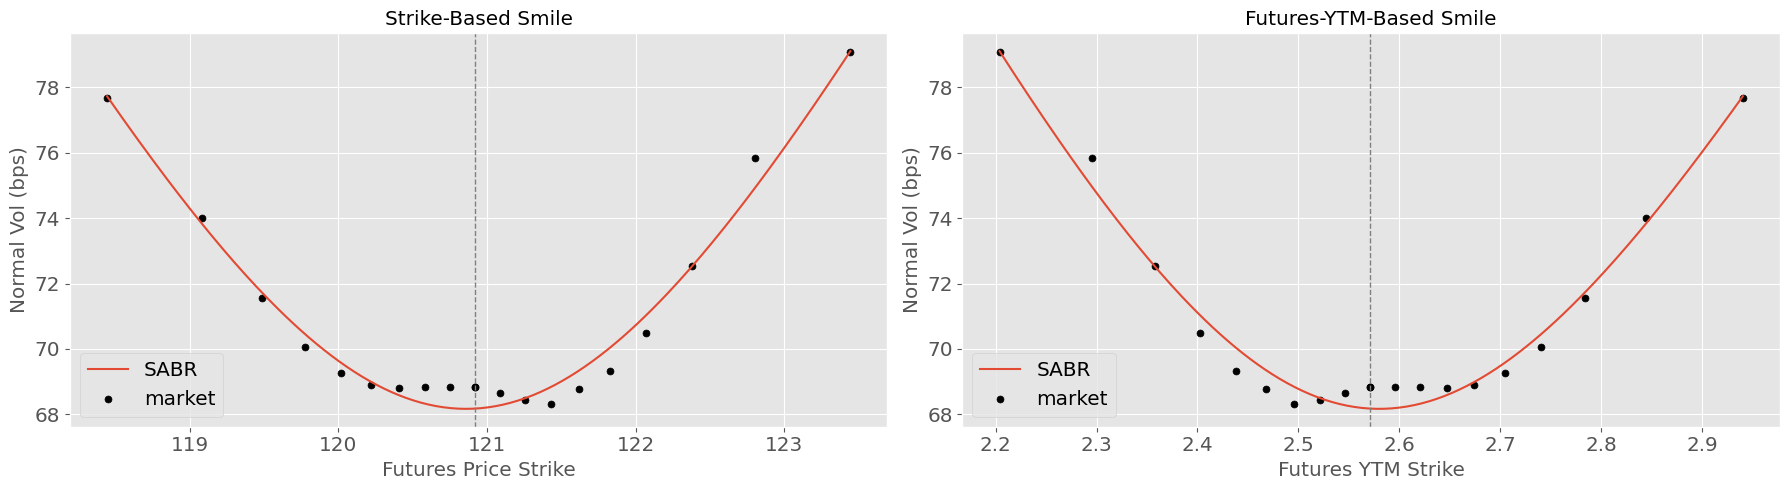

In [9]:
smile = ustfo_qs_mdp.fetch_sabr_smile(
	{
		"globex_symbol": "TY_30",
		"as_of": datetime.date(2018, 3, 13),
		"show_tqdm": True,
        # "force_refresh": True,
	}
)
# smile = ustfo_bc_mdp.fetch_sabr_smile(
# 	{
# 		"globex_symbol": "TYK26",
# 		"as_of": datetime.date(2026, 3, 12),
# 		"show_tqdm": True,
#         # "force_refresh": True,
# 	}
# )
print(smile.params)
print("forward price:", smile.params.forward_price)
print("forward futures ytm:", smile.params.forward_futures_ytm)
print("fv01:", smile.fv01)

# strike-based grid
price_strikes = np.linspace(
    min(p.strike_price for p in smile.points),
    max(p.strike_price for p in smile.points),
    200,
)
price_vols_bps = smile.normal_vol(price_strikes, strike_space="price", vol_units="bps")

# YTM-based grid
ytm_strikes = np.linspace(
    min(p.strike_futures_ytm for p in smile.points),
    max(p.strike_futures_ytm for p in smile.points),
    200,
)
ytm_vols_bps = smile.normal_vol(ytm_strikes, strike_space="futures_ytm", vol_units="bps")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(price_strikes, price_vols_bps, label="SABR")
axes[0].scatter([p.strike_price for p in smile.points], [p.iv_normal_bps for p in smile.points], s=25, c="black", label="market")
axes[0].axvline(smile.params.forward_price, ls="--", lw=1, c="gray")
axes[0].set_title("Strike-Based Smile")
axes[0].set_xlabel("Futures Price Strike")
axes[0].set_ylabel("Normal Vol (bps)")
axes[0].legend()

axes[1].plot(ytm_strikes, ytm_vols_bps, label="SABR")
axes[1].scatter([p.strike_futures_ytm for p in smile.points], [p.iv_normal_bps for p in smile.points], s=25, c="black", label="market")
axes[1].axvline(smile.params.forward_futures_ytm, ls="--", lw=1, c="gray")
axes[1].set_title("Futures-YTM-Based Smile")
axes[1].set_xlabel("Futures YTM Strike")
axes[1].set_ylabel("Normal Vol (bps)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [64]:
from RVUtils.ImpliedDistribution import (
    SFRImpliedDistribution,
    FedScenarioConfig,
    plot_snapshot_dashboard,
    plot_rnd_comparison,
	plot_distribution_change,
	resolve_strip_symbols,
    plot_strip_distribution_change,
)

FETCHING EOD DATA FROM BARCHART...: 100%|██████████| 52/52 [00:13<00:00,  3.91it/s]


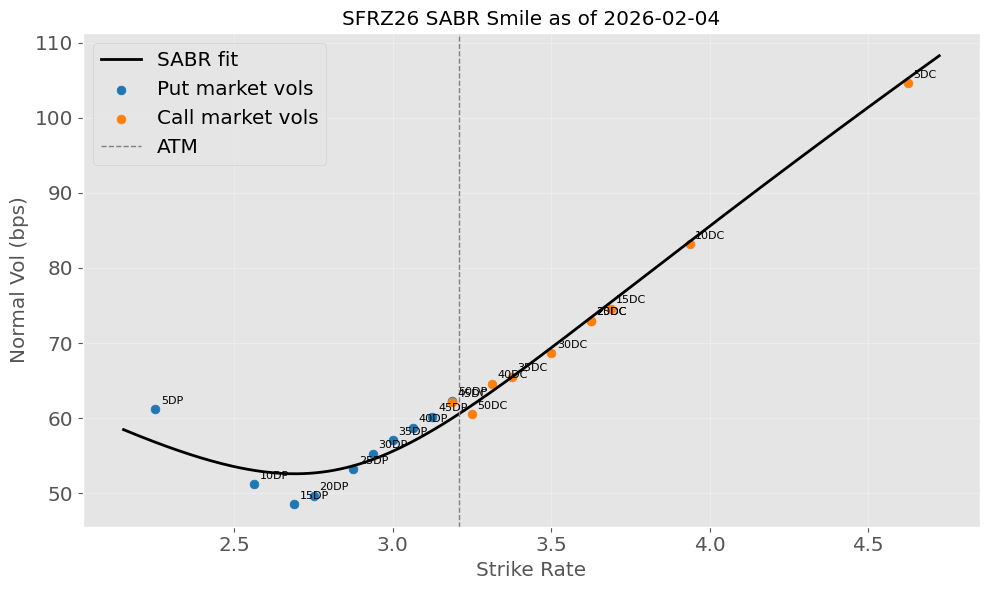

In [5]:
smile = mdp.fetch_sabr_smile({
    "symbol": "SFRZ26",
    # "as_of": "live", 
    "as_of": datetime.date(2026, 2, 4), 
	# "strike_offsets_bps": "listed",
	# "strike_offsets_bps": [5, 10, 25, 50, 75, 100],
    "show_tqdm": True,
    # "force_refresh": True,
})
plot_sfr_smile(smile)

# print(f"Forward: {smile.params.forward_price} (rate: {smile.params.forward_rate:.3f}%)")
# print(f"Expiry: {smile.params.expiry_date}, TTE: {smile.params.time_to_expiry:.4f}y")
# print(f"SABR: α={smile.params.alpha:.4f}, ρ={smile.params.rho:.4f}, ν={smile.params.nu:.4f}")
# print(f"Strikes: {len(smile.points)}")

# # 2. Define Fed scenarios (adjust current_rate to match current Fed funds)
# scenarios = FedScenarioConfig.default_sofr_scenarios(
#     current_rate=3.64,
#     n_cuts_range=[-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6],
#     default_std_bps=None,  # optimize std devs
#     # scenarios_only=True,  # only use discrete scenarios without BL component
# )

# # 3. Extract both BL and GM distributions
# dist = SFRImpliedDistribution(scenario_config=scenarios)
# snapshot = dist.extract(smile)

# # 4. Print BL summary
# bl = snapshot.bl_result
# # print(f"\n--- Breeden-Litzenberger ---")
# # print(f"Mean: {bl.mean_rate:.3f}%, Std: {bl.std_rate:.3f}%")
# # print(f"Skew: {bl.skewness:.3f}, Kurt: {bl.kurtosis:.3f}")
# # print(f"Percentiles: 5th={bl.percentile(5):.3f}%, 50th={bl.percentile(50):.3f}%, 95th={bl.percentile(95):.3f}%")

# # 5. Print GM scenario weights
# gm = snapshot.gm_result
# print(f"\n--- Gaussian Mixture (RMSE: {gm.rmse_price:.6f}) ---")
# for s, w, std in zip(gm.scenarios, gm.weights, gm.fitted_std_rates):
#     if w > 0.01:
#         print(f"  {s.label}: {w:.1%}  (σ={std*100:.1f}bp)")

# # 6. Plot dashboard
# fig = plot_snapshot_dashboard(snapshot)
# fig.savefig("sfrz26_implied_dist_20260311.png", dpi=150, bbox_inches="tight")

# # 7. Overlay comparison
# fig2 = plot_rnd_comparison(bl, gm)


FETCHING OPTION QUOTES...: 100%|██████████| 1/1 [00:00<00:00,  1.77it/s]


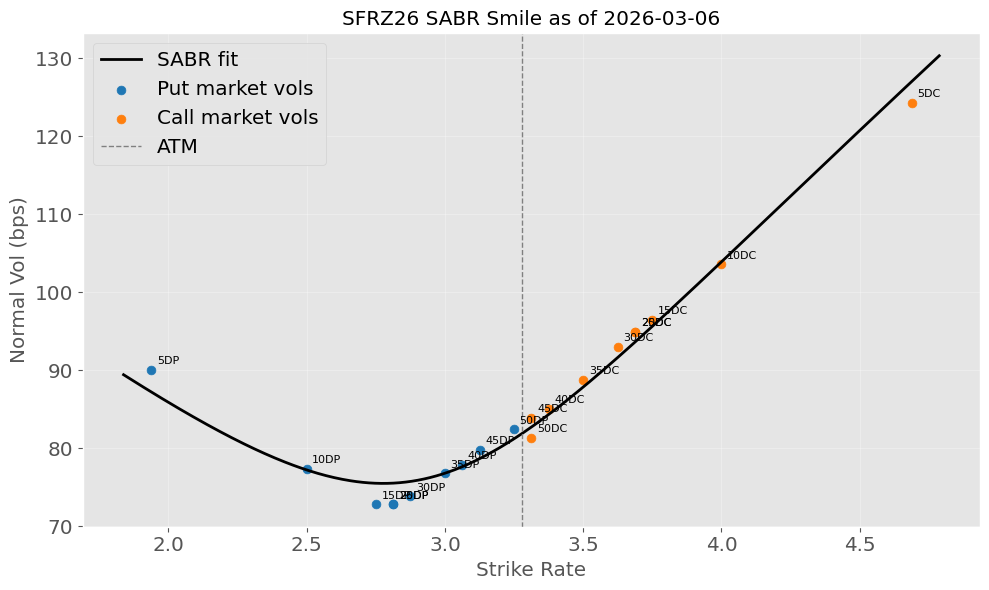

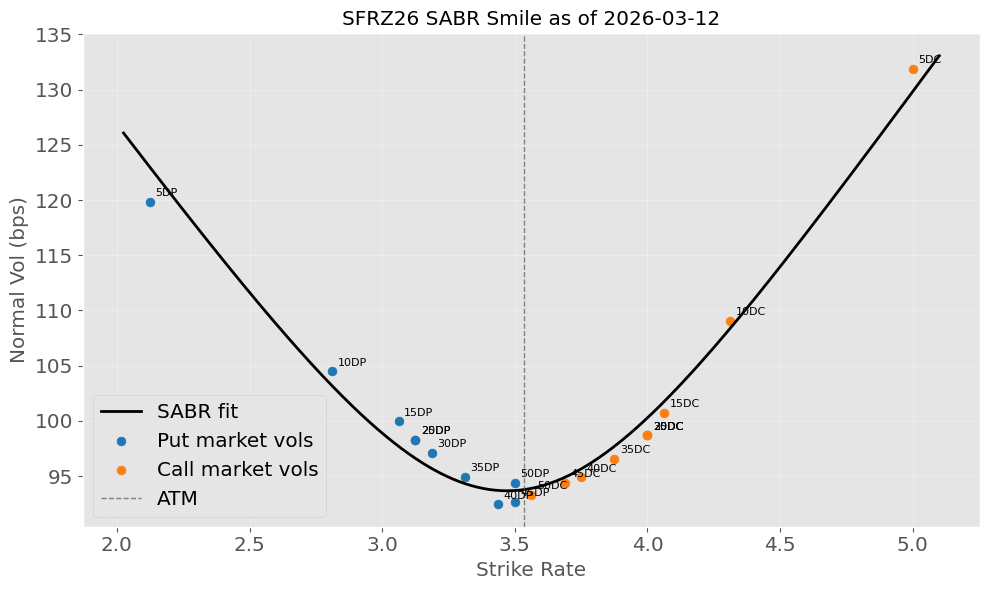

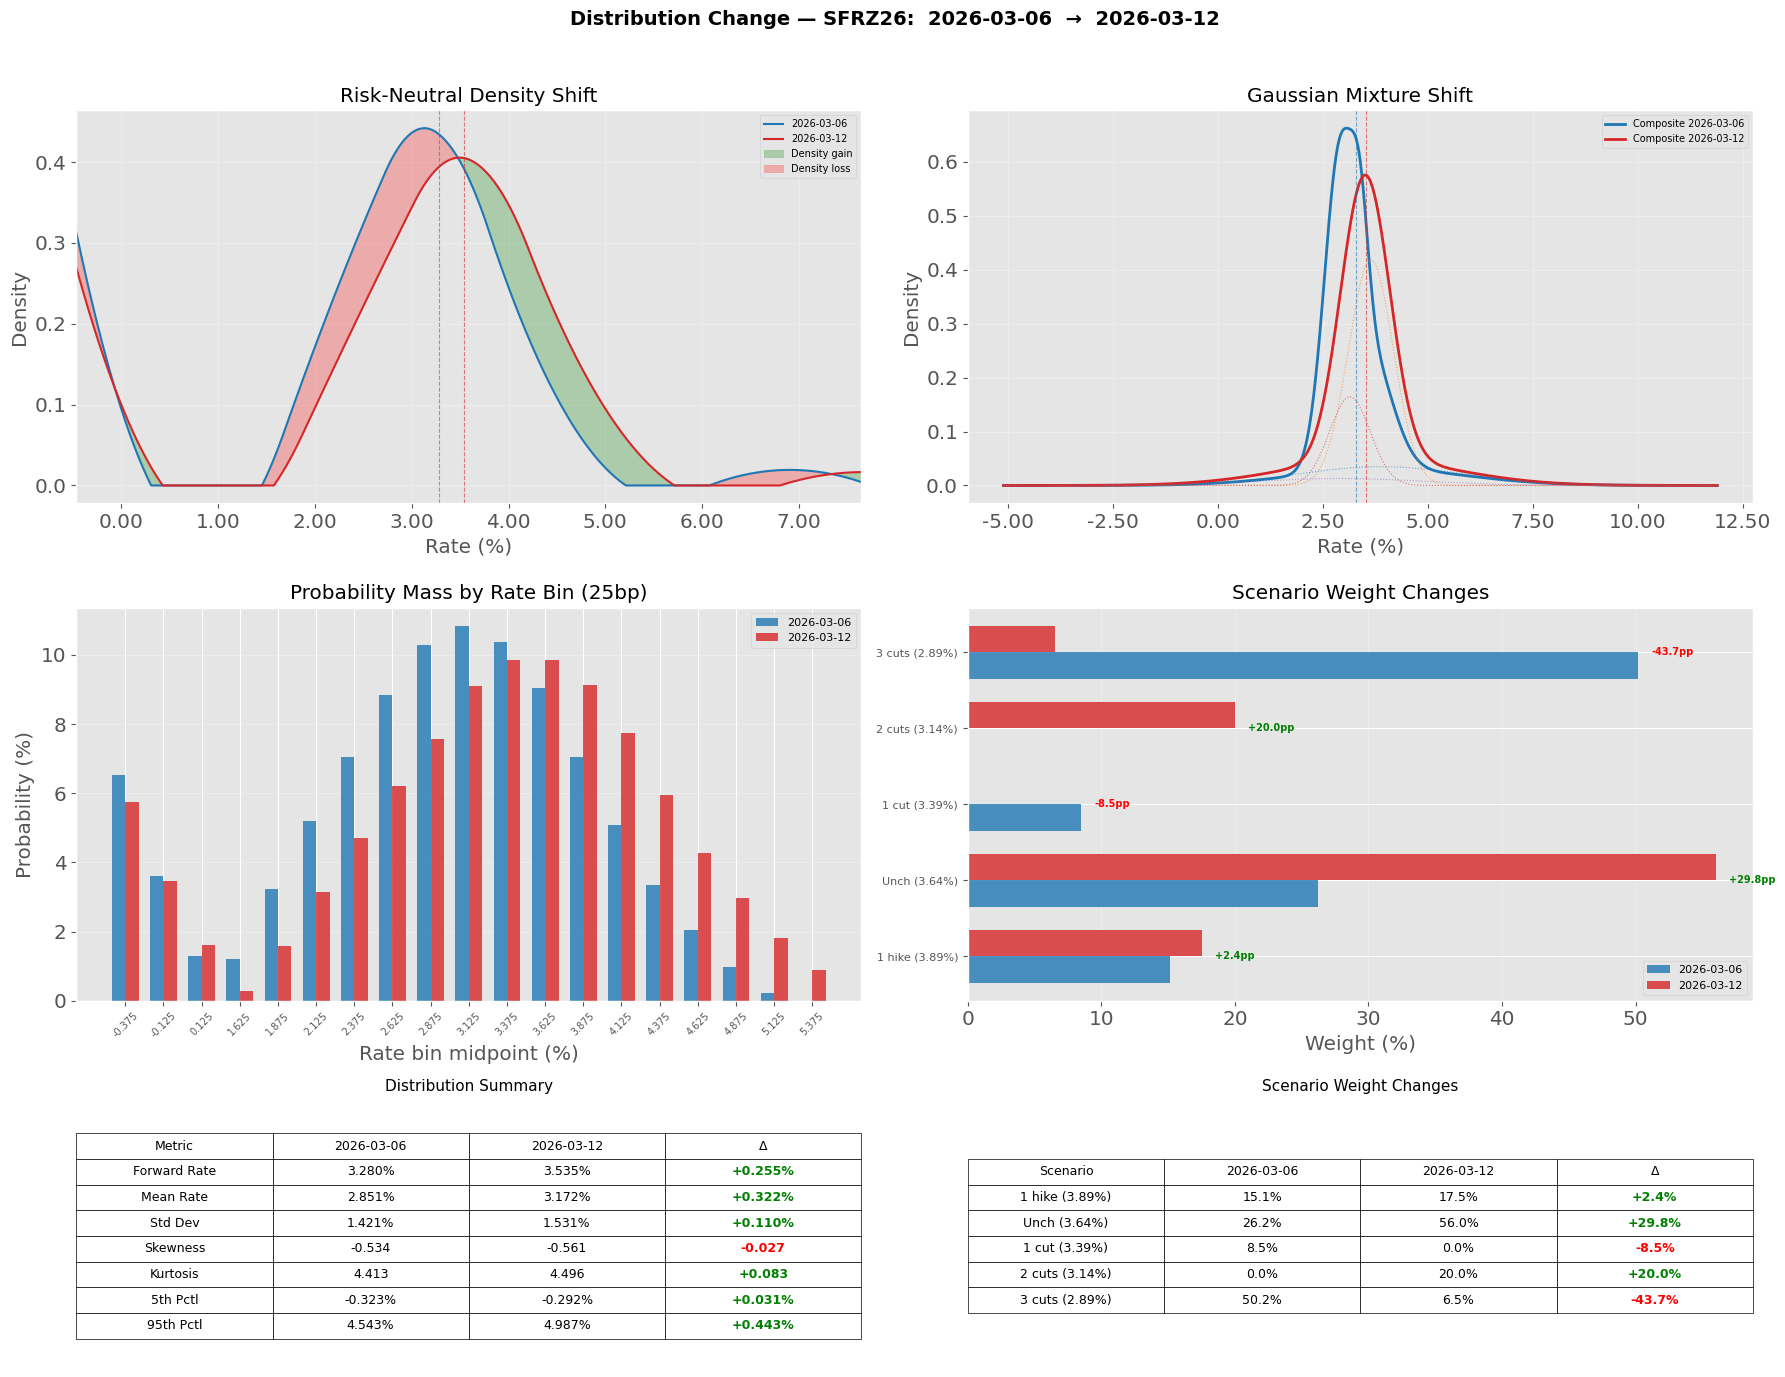

In [47]:
config = FedScenarioConfig.default_sofr_scenarios(
    current_rate=3.64, n_cuts_range=[-1, 0, 1, 2, 3]
)
dist = SFRImpliedDistribution(scenario_config=config)

smile_mar2 = mdp.fetch_sabr_smile({
    "symbol": "SFRZ26",
    "as_of": datetime.date(2026, 3, 6),
    # "strike_offsets_bps": "listed",
    # "force_refresh": True,
    "show_tqdm": True,
})
plot_sfr_smile(smile_mar2)

smile_live = mdp.fetch_sabr_smile({
    "symbol": "SFRZ26",
    "as_of": datetime.date(2026, 3, 12),
    # "as_of": "live", 
    # "strike_offsets_bps": "listed",
    "show_tqdm": True,
})
plot_sfr_smile(smile_live)

snap_before, snap_after = dist.compare(smile_mar2, smile_live)
fig = plot_distribution_change(snap_before, snap_after)

c:\Users\chris\anaconda3\envs\stir\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds

c:\Users\chris\anaconda3\envs\stir\Lib\site-packages\scipy\optimize\_slsqp_py.py:439: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds

c:\Users\chris\anaconda3\envs\stir\Lib\site-packages\scipy\optimize\_slsqp_py.py:493: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds

c:\Users\chris\anaconda3\envs\stir\Lib\site-packages\scipy\optimize\_slsqp_py.py:499: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds



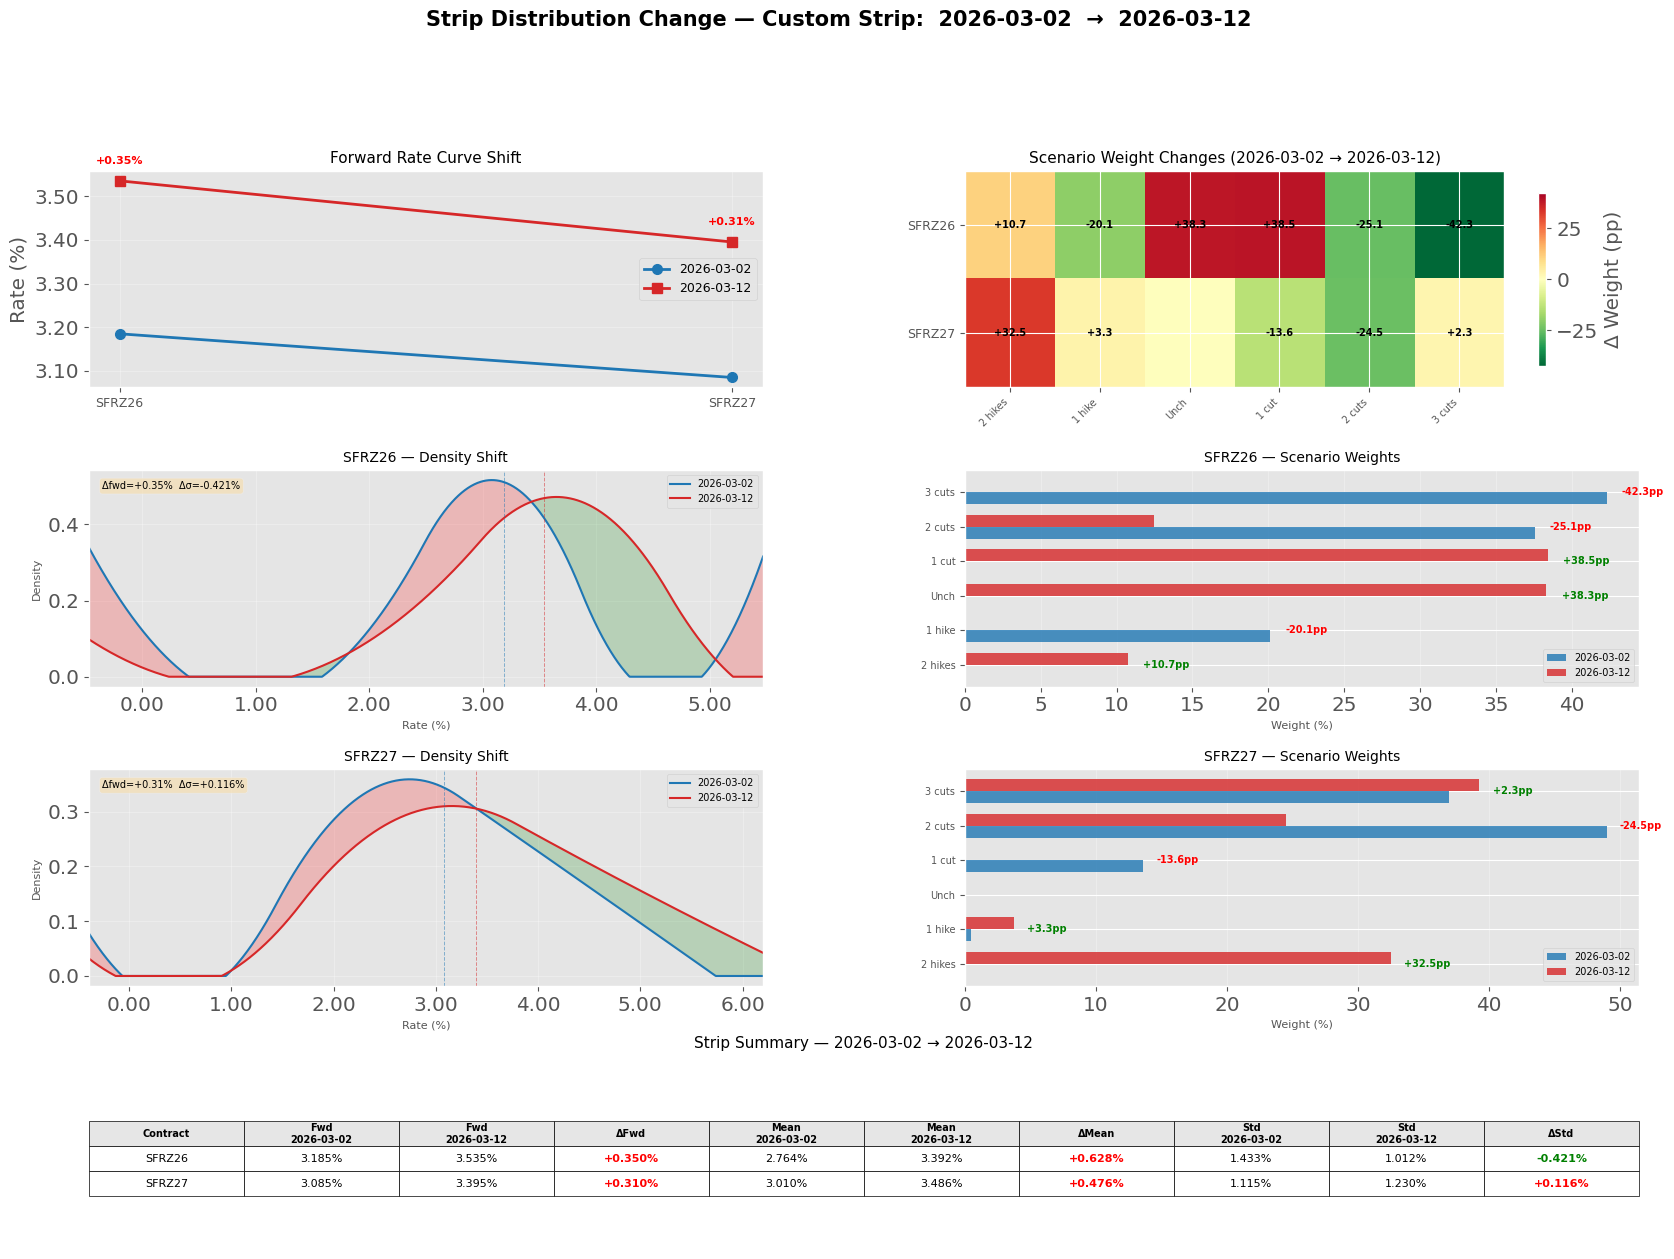

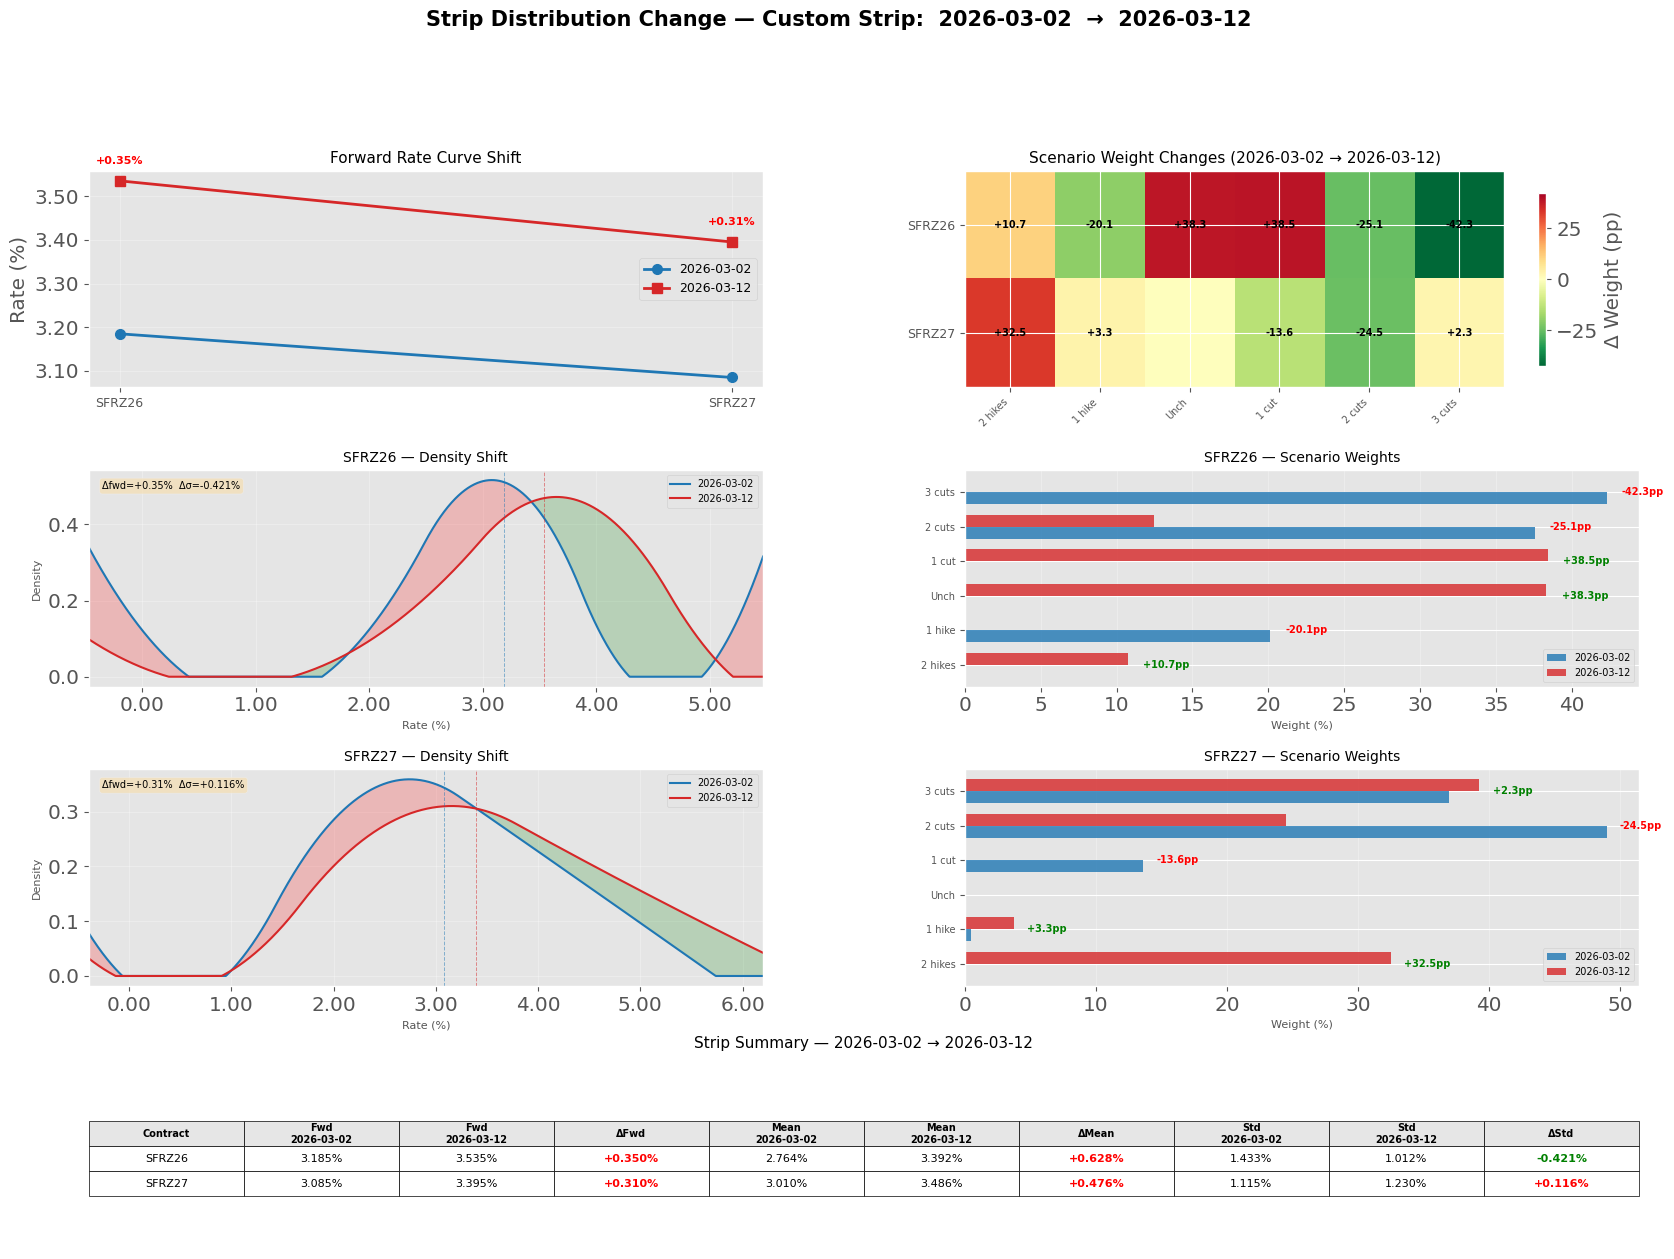

In [11]:
date1 = datetime.date(2026, 3, 2)
date2 = datetime.date(2026, 3, 12)

syms = ["SFRZ26", "SFRZ27"]
# syms = resolve_strip_symbols("whites", as_of=date2)

# Fetch smiles at both dates
smiles_d1 = {s: mdp.fetch_sabr_smile({"symbol": s, "as_of": date1}) for s in syms}
smiles_d2 = {s: mdp.fetch_sabr_smile({"symbol": s, "as_of": date2}) for s in syms}


scenarios = FedScenarioConfig.default_sofr_scenarios(
    current_rate=3.64,
    n_cuts_range=[-2, -1, 0, 1, 2, 3],
    default_std_bps=None,  # optimize std devs
)

dist = SFRImpliedDistribution(scenario_config=scenarios, sabr_rate_ceiling_nstdev=3)
result = dist.compare_strip(smiles_d1, smiles_d2, symbols=syms, as_of=date2)
plot_strip_distribution_change(result)

# Or with explicit symbols:
# result = dist.compare_strip(smiles_d1, smiles_d2, symbols=["SFRZ26", "SFRZ27"])

In [23]:
from MDP.STIRFutures.SCHWAB.schwab_simple import get_quotes
quotes = get_quotes(
	symbols=["./SR3Z26P96.5", "./SR3Z26C96.5"],
)

quotes

{'./SR3Z26P96.5': {'bid': 0.3075,
  'ask': 0.32,
  'mid': 0.31375,
  'last': 0.3125,
  'bidSize': 1352,
  'askSize': 544,
  'mark': 0.3125,
  'netChange': -7.40740741,
  'quoteTime': 1773422799796},
 './SR3Z26C96.5': {'bid': 0.31,
  'ask': 0.3225,
  'mid': 0.31625000000000003,
  'last': 0.3825,
  'bidSize': 838,
  'askSize': 410,
  'mark': 0.32,
  'netChange': 5.78512397,
  'quoteTime': 1773422799796}}

In [7]:
import ujson
from Query.STIRFutureOptions.STIRFutureOptionQuery import STIRFutureOptionQuery
from Query.STIRFutureOptions.STIRFutureOptionStructure import STIRFutureOptionStructure
from Query.STIRFutureOptions.STIRFutureOptionValue import STIRFutureOptionValue

q = STIRFutureOptionQuery(
    structure=STIRFutureOptionStructure.OUTRIGHT,
    value=STIRFutureOptionValue.PRICE,
    symbol="SFRZ26|ATMS",  
    market_request={
        "endpoint": "option_snapshot",
        "timestamp": "live",
        "use_ql_calculator": True,
    },
)
req = q.build_mdp_request()
pr = mdp.get_pricer(req)

package, weights = q.resolve_package(pricer_or_curve=pr)
value_map = q.build_value_map(
    pricer_or_curve=pr,
    package=package,
    risk_weights=weights,
)

print("resolved_symbol:", package[0].symbol())
print("price:", value_map.apply(STIRFutureOptionValue.PRICE))
print("iv_normal_bps:", value_map.apply(STIRFutureOptionValue.IV_NORMAL_BPS))
print("delta:", value_map.apply(STIRFutureOptionValue.DELTA))
print("gamma:", value_map.apply(STIRFutureOptionValue.GAMMA))
print("vega:", value_map.apply(STIRFutureOptionValue.VEGA))
print("theta:", value_map.apply(STIRFutureOptionValue.THETA))
print("raw quote:", ujson.dumps(value_map.apply(STIRFutureOptionValue.RAW_QUOTE), indent=4))

resolved_symbol: SFRZ26|9650S
price: 0.6312500000000001
iv_normal_bps: 90.64959089822237
delta: 0.007564055532853553
gamma: 1.008510523285055
vega: 0.6963001855046218
theta: -0.41436248812586096
raw quote: {
    "SFRZ26|9650C": {
        "bid": 0.3125,
        "ask": 0.3275,
        "mid": 0.32,
        "last": 0.3825,
        "bidSize": 497,
        "askSize": 554,
        "mark": 0.3225,
        "netChange": 6.61157025,
        "quoteTime": 1773423781743
    },
    "SFRZ26|9650P": {
        "bid": 0.305,
        "ask": 0.3175,
        "mid": 0.31125,
        "last": 0.3125,
        "bidSize": 543,
        "askSize": 186,
        "mark": 0.31,
        "netChange": -8.14814815,
        "quoteTime": 1773423782040
    }
}
